# 08 · Prophet

Every model so far has been **dynamic**: it forecasts tomorrow from what happened today. **Prophet**, released by Facebook's data science team in 2017 (Taylor & Letham, *Forecasting at Scale*), takes a completely different approach. It treats forecasting as **curve fitting**: describe the series as a smooth function of the *calendar*, fit that function, and extend it into the future.

Prophet became hugely popular because it's easy to use, its parts are easy to explain, and it handles things classical models find awkward: missing data, several seasonal cycles at once, and holidays. It's also been widely criticised for losing to simple methods on benchmark after benchmark. This chapter gives it a fair hearing, on the same backtests as everything else, and works out *why* it wins or loses.

**By the end of this chapter you will be able to**

- describe Prophet's decomposition into **trend**, **seasonality** and **holidays**
- build **Fourier seasonal features** from scratch and see how their order controls flexibility
- explain Prophet's **changepoint** trend, and diagnose a common failure it causes
- add **holiday effects**, here Beijing's Spring Festival fireworks
- add **extra regressors** that are known in advance, and evaluate with Prophet's built-in **cross-validation**
- use a **logistic trend with a capacity** for series that saturate
- recognise what Prophet lacks (**autoregression**) and repair it with a hybrid model
- decide when Prophet is the right tool

In [1]:
import logging
import warnings
logging.getLogger("prophet.plot").disabled = True        # plotly isn't needed; silence its import notice
warnings.filterwarnings("ignore", message="IProgress not found")   # progress-bar notice from Prophet's import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from prophet import Prophet
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

import tsutils

logging.getLogger("cmdstanpy").disabled = True             # Prophet's optimiser logs every fit
tsutils.set_style()
pd.set_option("display.precision", 3)

daily = tsutils.load_daily_pm25()
y, actual = daily["pm25"], daily["actual"]
origins, H = tsutils.BACKTEST_ORIGINS, tsutils.HORIZON
co2 = sm.datasets.co2.load_pandas().data["co2"].resample("MS").mean().interpolate()

---
## 1. The model

Prophet writes a series as a sum of functions of time:

$$y(t) = g(t) + s(t) + h(t) + \varepsilon_t$$

| Term | What it is | How it's built |
|---|---|---|
| $g(t)$ | **trend** | piecewise-linear, with automatically placed **changepoints** |
| $s(t)$ | **seasonality** | **Fourier series** for yearly, weekly (and optionally daily) cycles |
| $h(t)$ | **holidays / events** | an extra effect on listed dates, with optional windows around them |
| $\varepsilon_t$ | error | assumed independent noise |

Statistically, this is a regression on functions of time (a generalised additive model), fitted with the Stan library.

Notice what's **not** in the list. There's no term for *the value yesterday*. Prophet's forecast for tomorrow depends on the date, not on what the series did today, except indirectly, through a refit. Keep that in mind; it will explain most of this chapter's results.

Prophet expects a data frame with two columns, `ds` (dates) and `y` (values):

In [2]:
def to_prophet(series, log=False):
    return pd.DataFrame({"ds": series.index, "y": np.log(series.to_numpy()) if log else series.to_numpy()})

to_prophet(co2).head(3)

,ds,y
0,1958-03-01,316.100
1,1958-04-01,317.200
2,1958-05-01,317.433


---
## 2. Seasonality as a Fourier series

A seasonal pattern of period $P$ (365.25 days for yearly, 7 for weekly) is modelled as a sum of sine and cosine waves:

$$s(t) = \sum_{k=1}^{K} \left[ a_k \sin\!\left(\frac{2\pi k t}{P}\right) + b_k \cos\!\left(\frac{2\pi k t}{P}\right) \right]$$

The **order** $K$ controls flexibility. $K = 1$ gives a single smooth wave, and larger $K$ can trace sharper shapes but also chase noise. Prophet's defaults are $K = 10$ for yearly and $K = 3$ for weekly seasonality.

These sine and cosine columns are ordinary regression features, so let's build them ourselves and see what different orders can express, using CO₂'s detrended seasonal wiggle as the target.

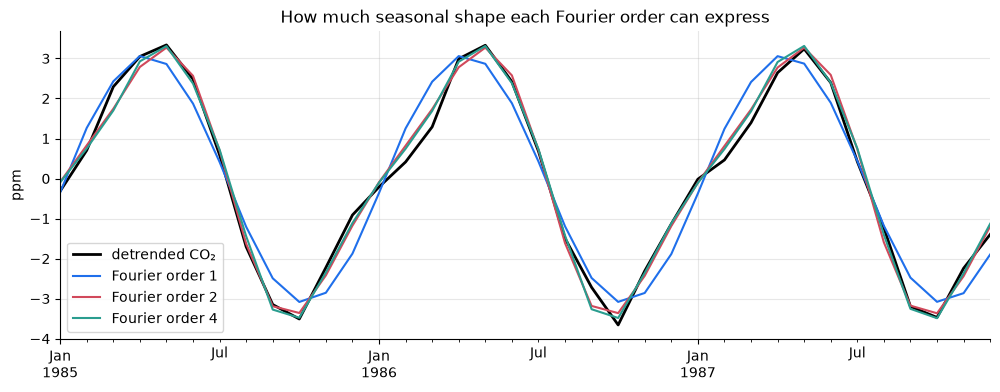

In [3]:
def fourier_features(dates, period, order):
    """sin/cos pairs for k = 1..order, with t measured in days since 1970-01-01 (as Prophet does)."""
    t = ((pd.Series(dates) - pd.Timestamp("1970-01-01")).dt.total_seconds() / 86400).to_numpy()
    return np.column_stack([f(2 * np.pi * k * t / period) for k in range(1, order + 1) for f in (np.sin, np.cos)])

sample = co2["1980":"1989"]
wiggle = sample - sample.rolling(13, center=True).mean()          # remove the trend, keep the cycle
wiggle = wiggle.dropna()

fig, ax = plt.subplots()
wiggle["1985":"1987"].plot(ax=ax, color="k", lw=2, label="detrended CO₂")
for order in [1, 2, 4]:
    X = np.column_stack([np.ones(len(wiggle)), fourier_features(wiggle.index, 365.25, order)])
    coefs = np.linalg.lstsq(X, wiggle.to_numpy(), rcond=None)[0]
    pd.Series(X @ coefs, index=wiggle.index)["1985":"1987"].plot(ax=ax, label=f"Fourier order {order}")
ax.set(title="How much seasonal shape each Fourier order can express", ylabel="ppm")
ax.legend();

One wave (order 1) gets the timing roughly right but misses the shape: CO₂ falls quickly in the northern summer and recovers slowly. Order 2 captures that asymmetry, and order 4 adds little more. For a smooth annual cycle, a handful of terms is plenty. Exercise 1 checks that these features match Prophet's own.

---
## 3. The trend: changepoints

Prophet's trend is a straight line whose slope can change at a set of **changepoints**. By default it places 25 candidate changepoints, evenly spread over the **first 80%** of the history. Each can change the slope, but a sparsity-inducing prior (Laplace, scale `changepoint_prior_scale`, default 0.05) keeps most changes at or near zero. Larger values allow a wigglier trend.

Let's fit Prophet to CO₂ up to January 1995 and look at the components:

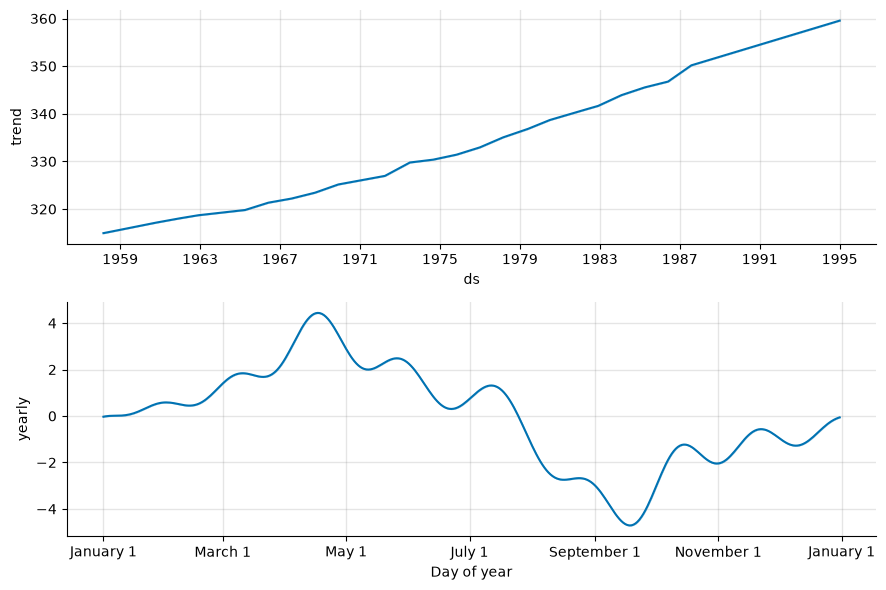

In [4]:
co2_history = co2[:"1995-01"]
co2_model = Prophet(weekly_seasonality=False, daily_seasonality=False).fit(to_prophet(co2_history))
co2_fit = co2_model.predict(to_prophet(co2_history))
co2_model.plot_components(co2_fit);

lag-1 autocorrelation of residuals: 0.64


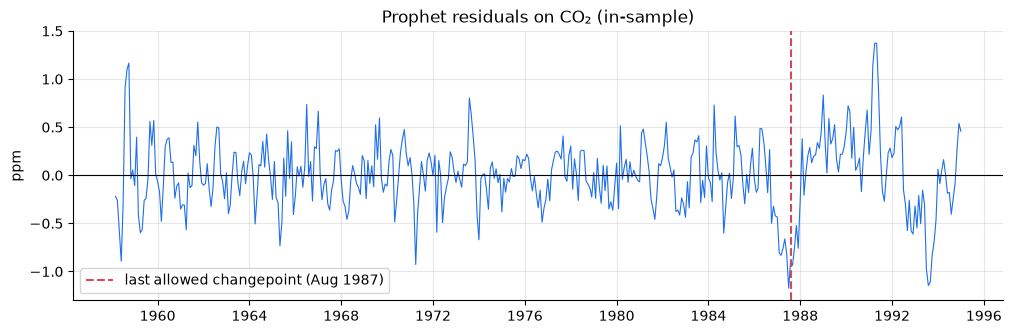

In [5]:
residuals = co2_history.to_numpy() - co2_fit["yhat"].to_numpy()
last_changepoint = co2_model.changepoints.iloc[-1]

fig, ax = plt.subplots(figsize=(12, 3.5))
ax.plot(co2_history.index, residuals, lw=0.8)
ax.axvline(last_changepoint, color="#d1495b", ls="--", label=f"last allowed changepoint ({last_changepoint:%b %Y})")
ax.axhline(0, color="k", lw=0.8)
ax.set(title="Prophet residuals on CO₂ (in-sample)", ylabel="ppm")
ax.legend(loc="lower left")
print(f"lag-1 autocorrelation of residuals: {pd.Series(residuals).autocorr(1):.2f}")

Two warning signs:

1. **The residuals are strongly autocorrelated.** When the fitted curve is too high one month, it's too high the next month too. That's information about the near future which Prophet doesn't use, because it has no autoregressive term.
2. **After the last allowed changepoint, the trend can't bend.** The final 20% of the history, here about seven years, is forced onto one slope. CO₂'s growth did shift in that window, including the well-known slowdown after the 1991 Pinatubo eruption, so the residuals drift in long runs, and the forecast starts from the wrong place.

Let's see what that costs in the backtest, against chapter 04's baseline and chapter 07's airline model, on the same quarterly origins.

In [6]:
co2_origins = pd.date_range("1990-01-01", "2000-12-01", freq="QS")

def prophet_co2(history, horizon, hybrid=False, **settings):
    model = Prophet(weekly_seasonality=False, daily_seasonality=False, uncertainty_samples=0, **settings)
    model.fit(to_prophet(history))
    dates = pd.date_range(history.index[0], periods=len(history) + horizon, freq="MS")
    curve = model.predict(pd.DataFrame({"ds": dates}))["yhat"].to_numpy()
    forecast = curve[len(history):]
    if hybrid:                                   # model the memory Prophet leaves in its residuals
        resid = history.to_numpy() - curve[:len(history)]
        forecast = forecast + AutoReg(resid, lags=2, trend="n").fit().predict(start=len(resid), end=len(resid) + horizon - 1)
    return forecast

def seasonal_naive_drift(history, horizon, period=12):
    growth = history.iloc[-period:].mean() - history.iloc[-2 * period:-period].mean()
    last_year = np.tile(history.iloc[-period:].to_numpy(), int(np.ceil(horizon / period)))[:horizon]
    return last_year + growth * np.ceil(np.arange(1, horizon + 1) / period)

def airline(history, horizon):
    return SARIMAX(history, order=(0, 1, 1), seasonal_order=(0, 1, 1, 12)).fit(disp=False).forecast(horizon).to_numpy()

co2_models = {
    "baseline: seasonal naive + drift": seasonal_naive_drift,
    "SARIMA airline (ch. 07)": airline,
    "Prophet (defaults)": prophet_co2,
    "Prophet, changepoints over 95% of history": lambda h, H_: prophet_co2(h, H_, changepoint_range=0.95),
    "Prophet 95% + AR(2) on residuals": lambda h, H_: prophet_co2(h, H_, hybrid=True, changepoint_range=0.95),
}
co2_table = pd.DataFrame({name: tsutils.evaluate(tsutils.backtest(co2, f, co2_origins, 12))["MAE"]
                          for name, f in co2_models.items()})
co2_table.loc[[1, 3, 6, 12]].T

h,1,3,6,12
baseline: seasonal naive + drift,0.494,0.564,0.683,0.842
SARIMA airline (ch. 07),0.218,0.310,0.437,0.643
Prophet (defaults),0.747,0.828,0.917,1.063
"Prophet, changepoints over 95% of history",0.489,0.557,0.714,1.007
Prophet 95% + AR(2) on residuals,0.327,0.514,0.707,1.007


**With its defaults, Prophet loses to the simple baseline at every horizon**, and to the airline model by a wide margin. The diagnosis above points to the fixes:

- **Let the trend bend later.** `changepoint_range=0.95` allows changepoints up to near the end of the history. That removes most of the short-horizon gap to the baseline. It's the single most useful Prophet setting to know about.
- **Add the missing memory.** Fitting an AR(2) to Prophet's residuals and adding its forecast (a *hybrid*) helps further at short horizons.

Even repaired, Prophet doesn't reach the airline model or Holt-Winters on this series. CO₂ is exactly the kind of smooth, persistent series where dynamic models shine: they update their level every month, while Prophet re-draws one global curve.

---
## 4. Holidays: Spring Festival fireworks in Beijing

Prophet's most distinctive feature is **holiday effects**. Our data contain a spectacular one. On the eve of the Lunar New Year (Spring Festival), Beijing celebrated with city-wide **fireworks** from the evening past midnight. Look at the hourly readings on those nights:

In [7]:
spring_festival = pd.to_datetime(["2010-02-14", "2011-02-03", "2012-01-23",
                                  "2013-02-10", "2014-01-31", "2015-02-19"])    # Lunar New Year's Day

hourly_pm = tsutils.load_beijing()["pm25"]
rows = []
for new_year in spring_festival:
    night = hourly_pm[new_year - pd.Timedelta(hours=6): new_year + pd.Timedelta(hours=6)]    # 18:00 on the eve to 06:00
    around = y[new_year - pd.Timedelta(days=10): new_year + pd.Timedelta(days=10)]
    rows.append({"New Year's Day": new_year.date(), "peak hour that night": night.max(),
                 "daily mean on New Year's Day": y[new_year], "typical day ±10 days (median)": around.median()})
pd.DataFrame(rows).set_index("New Year's Day").round(0)

,peak hour that night,daily mean on New Year's Day,typical day ±10 days (median)
New Year's Day,,,
2010-02-14,980.0,119.0,92.0
2011-02-03,348.0,110.0,53.0
2012-01-23,994.0,194.0,72.0
2013-02-10,512.0,60.0,68.0
2014-01-31,469.0,166.0,71.0
2015-02-19,407.0,189.0,111.0


The **highest reading in the entire six-year dataset**, 994 µg/m³, was recorded on Spring Festival night 2012. Because the fireworks peak around midnight, their effect lands mostly on the **daily mean of New Year's Day**.

Holidays are given to Prophet as a data frame of dates. `lower_window` and `upper_window` extend each date to the days around it, and each offset gets its own effect. Holiday dates are known years in advance, so using them in a forecast is completely honest. (Prophet also offers `add_country_holidays("CN")`, which uses the `holidays` package. Listing the one festival we care about keeps the effect clear.)

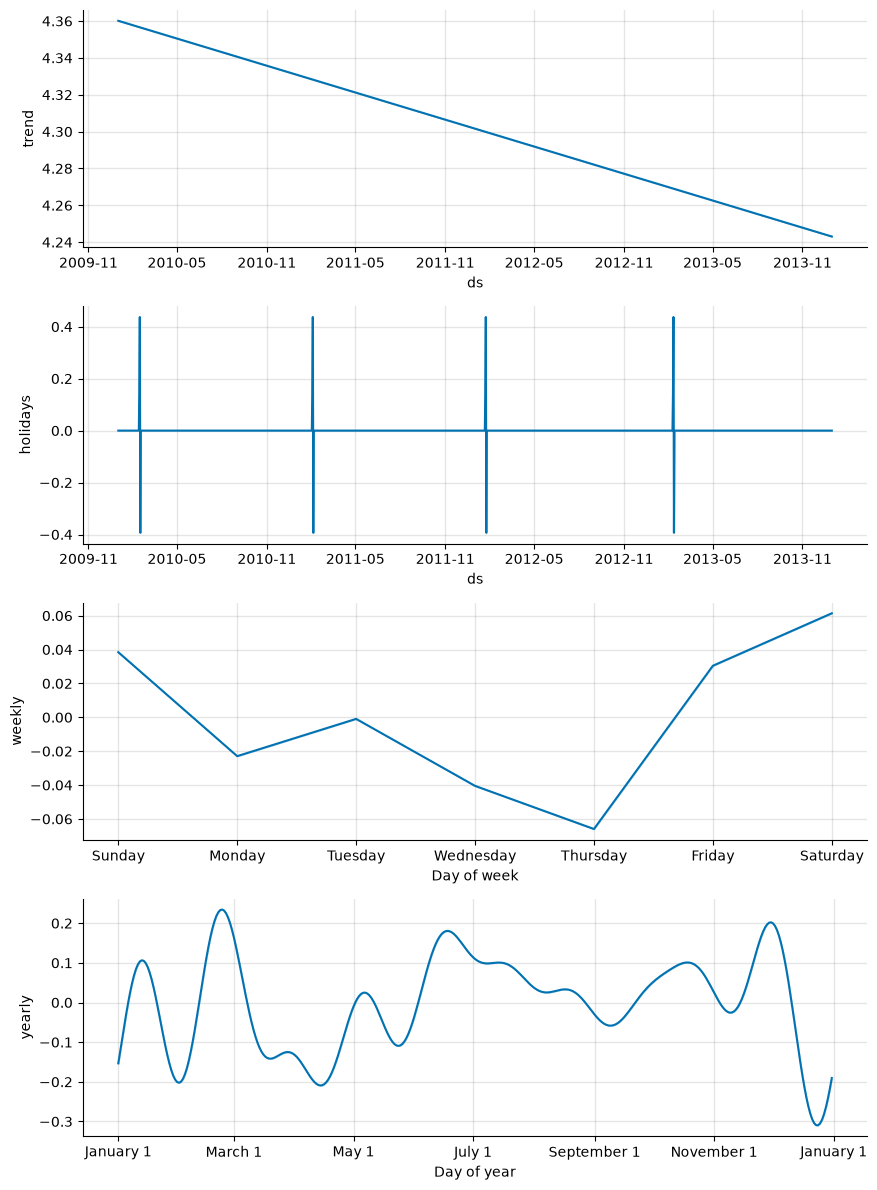

In [8]:
holidays = pd.DataFrame({"holiday": "spring_festival", "ds": spring_festival,
                         "lower_window": -1, "upper_window": 1})          # eve, day, and day after

train = y[:"2013-12-31"]
pm_model = Prophet(holidays=holidays).fit(to_prophet(train, log=True))
pm_fit = pm_model.predict(to_prophet(train, log=True))
pm_model.plot_components(pm_fit);

In [9]:
effect = pm_fit.loc[pm_fit["spring_festival"] != 0, ["ds", "spring_festival"]].copy()
effect["offset"] = (effect["ds"] - effect["ds"].map(lambda d: spring_festival[np.abs(spring_festival - d).argmin()])).dt.days
(effect.groupby("offset")["spring_festival"].first().pipe(np.exp).sub(1).mul(100).round(0)
 .rename("effect on PM2.5 (%)").rename_axis("days from New Year's Day").to_frame())

,effect on PM2.5 (%)
days from New Year's Day,
-1,15.0
0,55.0
1,-33.0


Prophet estimates that **New Year's Day runs roughly 50% above** what trend and season alone would predict. The eve is a little elevated too. The day *after* comes out below normal, perhaps because the smoke clears, or perhaps because it's fitting noise: with only four festivals in the training data, each estimate rests on four days. That's an important caveat with holiday effects. They're estimated from very few occurrences, and Prophet's prior (`holidays_prior_scale`) is what stops them from being overfitted.

Two more things in the components are worth a critical look:

- A **weekly** pattern of about ±6%, highest at the weekend. That's the same slight weekend excess chapter 01's Exercise 3 found, with the same caveat: a few smoggy weekends can produce it. Prophet fits weekly seasonality by default for daily data, whether or not the series has any.
- A very **wiggly yearly** curve. With the default Fourier order of 10 and only four noisy years, the yearly component bends to follow individual episodes, the over-flexibility section 2 warned about. Compare chapter 06's month-smoothed profile. A lower order (`yearly_seasonality=4`) would be more defensible.

Defaults are assumptions, and it's worth checking them.

---
## 5. The PM2.5 backtest

We refit Prophet at every origin, on the log scale with the Spring Festival holidays, and forecast 7 days. Then we test the **hybrid**: an AR(2) on Prophet's in-sample residuals, added to its forecast, much like chapter 06, but with Prophet supplying the seasonal curve. Both use the same Prophet fit, so we cache it per origin. Prophet refits take a little over two minutes in total here.

In [10]:
prophet_cache = {}

def fitted_prophet_curve(history, horizon):
    """In-sample fit and forecast of log PM2.5 from a Prophet refitted on `history` (cached per origin)."""
    origin = history.index[-1]
    if origin not in prophet_cache:
        model = Prophet(holidays=holidays, uncertainty_samples=0).fit(to_prophet(history, log=True))
        dates = pd.date_range(history.index[0], origin + pd.Timedelta(days=horizon), freq="D")
        curve = model.predict(pd.DataFrame({"ds": dates}))["yhat"].to_numpy()
        prophet_cache[origin] = (curve[:len(history)], curve[len(history):])
    return prophet_cache[origin]

def prophet_forecast(history, horizon):
    return np.exp(fitted_prophet_curve(history, horizon)[1][:horizon])

def prophet_ar_forecast(history, horizon):
    in_sample, future = fitted_prophet_curve(history, horizon)
    resid = np.log(history.to_numpy()) - in_sample
    ar = AutoReg(resid, lags=2, trend="n").fit()
    return np.exp(future[:horizon] + ar.predict(start=len(resid), end=len(resid) + horizon - 1))

prophet_scores = {
    "Prophet (log, holidays)": tsutils.evaluate(tsutils.backtest(y, prophet_forecast, origins, H, actuals=actual)),
    "Prophet + AR(2) on residuals": tsutils.evaluate(tsutils.backtest(y, prophet_ar_forecast, origins, H, actuals=actual)),
}
for name, scores in prophet_scores.items():
    tsutils.save_scores(name, scores)

board = tsutils.load_scores().pivot(index="h", columns="model", values="MAE")
board[["climatology (median)", "AR(2) on anomalies", "SARIMAX, today's weather",
       "Prophet (log, holidays)", "Prophet + AR(2) on residuals"]]

model,climatology (median),AR(2) on anomalies,"SARIMAX, today's weather","Prophet (log, holidays)",Prophet + AR(2) on residuals
h,,,,,
1,56.079,46.803,40.937,55.545,47.238
2,56.561,55.419,55.956,56.246,55.604
3,56.771,56.264,56.834,56.543,56.542
4,57.133,56.533,56.809,56.845,56.809
5,57.099,56.587,56.687,56.804,56.843
6,57.132,56.491,56.634,56.813,56.825
7,57.068,56.407,56.545,56.785,56.782


This is exactly what the model structure predicts:

- **Prophet alone behaves like a slightly better climatology**: nearly flat across horizons, a little ahead of the median climatology at short horizons because its trend tracks the recent level. It can't use the fact that today was smoggy, so it can't compete with AR(2) for tomorrow.
- **The hybrid recovers the memory.** Prophet's curve plus an AR(2) on its residuals lands at the same level as chapter 06's profile + AR(2). Prophet provides a perfectly good seasonal profile, but the forecasting skill at short horizons comes from the autoregressive part.
- **The honest weather model from chapter 07 still leads for tomorrow**, because it has information none of these models see.

The residuals confirm the diagnosis:

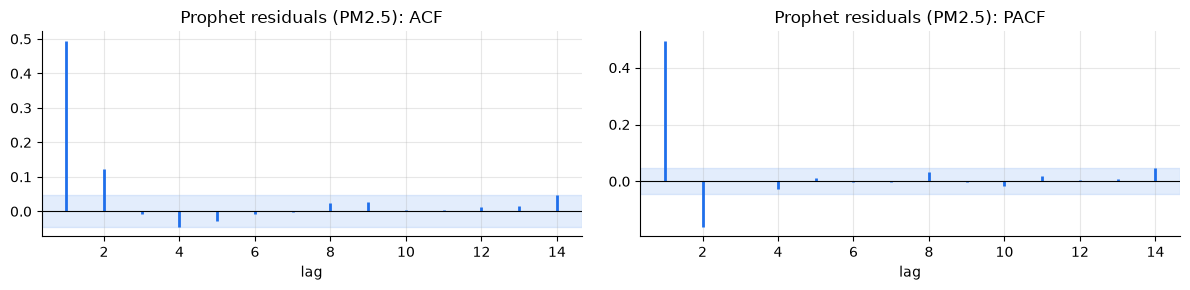

In [11]:
in_sample, _ = fitted_prophet_curve(y[:origins[-1]], H)
prophet_resid = pd.Series(np.log(y[:origins[-1]].to_numpy()) - in_sample, index=y[:origins[-1]].index)
tsutils.plot_acf_pacf(prophet_resid, lags=14, title="Prophet residuals (PM2.5):")

A lag-1 autocorrelation of about 0.5 and a PACF that cuts off after lag 2 is the same AR(2) fingerprint chapter 06 found in the anomalies. Prophet removed the seasonal pattern and left **all of the day-to-day memory** in its residuals.

---
## 6. Extra regressors, and Prophet's own cross-validation

Beyond trend, seasonality and holidays, Prophet accepts **extra regressors** with `add_regressor`: any column in the data frame, whose effect is estimated alongside everything else. The catch is the same as chapter 07's. **Prophet needs the regressor's value on every future date it forecasts.** That makes regressors that are *known in advance* the natural fit.

Beijing offers a good one. The city's central heating, much of it coal-fired in these years, officially runs from **15 November to 15 March**. The dates are fixed years ahead, so a heating-season flag is a perfectly honest input for any horizon.

In [12]:
def heating_season(dates):
    # 1 from 15 November to 15 March (Beijing's official central-heating period), else 0
    dates = pd.to_datetime(pd.Series(dates))
    month_day = dates.dt.month * 100 + dates.dt.day
    return ((month_day >= 1115) | (month_day <= 315)).astype(float).to_numpy()

development = to_prophet(y[:tsutils.DEV_END], log=True)
development["heating"] = heating_season(development["ds"])
development.groupby("heating")["y"].mean().pipe(np.exp).rename("geometric-mean PM2.5 (µg/m³)").to_frame()

,geometric-mean PM2.5 (µg/m³)
heating,
0.0,72.006
1.0,75.436


Now fit two versions, identical except for the regressor, and compare them with **Prophet's built-in cross-validation**. `prophet.diagnostics.cross_validation` is a rolling-origin backtest, just like chapter 04's:

- `initial`: how much history the first fit uses
- `period`: how far apart the forecast origins ("cutoffs") are
- `horizon`: how far ahead each forecast reaches

We start after four years of history (the end of 2013) and place a cutoff every 14 days through 2014, so, as always, only the development period is used. Prophet refits at every cutoff. `performance_metrics` then summarises the errors by horizon. Its errors are on whatever scale `y` is on, here log, so we also convert to µg/m³ ourselves.

In [13]:
from prophet.diagnostics import cross_validation
from prophet.utilities import regressor_coefficients

def prophet_cv(use_heating):
    model = Prophet(holidays=holidays, uncertainty_samples=0)
    if use_heating:
        model.add_regressor("heating")
    model.fit(development if use_heating else development.drop(columns="heating"))
    cv = cross_validation(model, initial="1460 days", period="14 days", horizon="7 days", disable_tqdm=True)
    cv["days_ahead"] = (cv["ds"] - cv["cutoff"]).dt.days
    cv["abs_error"] = np.abs(np.exp(cv["yhat"]) - np.exp(cv["y"]))
    return model, cv

base_model, base_cv = prophet_cv(use_heating=False)
heat_model, heat_cv = prophet_cv(use_heating=True)
print(f"{base_cv['cutoff'].nunique()} cutoffs, from {base_cv['cutoff'].min():%d %b %Y} to {base_cv['cutoff'].max():%d %b %Y}")

pd.DataFrame({"Prophet": base_cv.groupby("days_ahead")["abs_error"].mean(),
              "Prophet + heating regressor": heat_cv.groupby("days_ahead")["abs_error"].mean()}).round(1)

26 cutoffs, from 08 Jan 2014 to 24 Dec 2014


,Prophet,Prophet + heating regressor
days_ahead,,
1,50.2,50.2
2,47.3,47.3
3,62.2,62.2
4,55.2,55.3
5,60.5,60.5
6,55.7,55.7
7,77.2,77.1


In [14]:
regressor_coefficients(heat_model)[["regressor", "coef"]]

,regressor,coef
0,heating,0.166


The raw comparison is already a hint. On the log scale, the typical level is only about 5% higher inside the heating season, chapter 01's finding again: winter differs mainly in its *extremes*, which a log-scale average damps. In the model, the regressor gets a modest positive coefficient (about +18%, holding trend and seasonality fixed). Yet the cross-validated errors are **essentially identical**, to within 0.1 µg/m³. **The yearly seasonality already knows when winter is.** The flag mostly re-describes the calendar that Prophet's Fourier terms were modelling anyway, so the model can shift weight between the two without forecasting any better.

That's the general test for any extra input: **does it carry information the model doesn't already have?** Chapter 07's evening wind passed that test, because the calendar can't tell you tomorrow's wind. A heating-season flag mostly doesn't. (Its sharp edges could still matter for the exact switch-on date, which a smooth yearly curve blurs. That effect is too small to see in these averages.)

(Prophet's CV numbers aren't directly comparable with our scoreboard. They use 26 cutoffs instead of 359, on different days. Use Prophet's tools for quick experiments, and `tsutils.backtest` for the course leaderboard.)

---
## 7. Growth with a ceiling: the logistic trend

Prophet's default trend is piecewise *linear*, and a line continues forever. Many real quantities **saturate**: adoption of a product, cumulative cases in an outbreak, the share of households with a technology. For those, Prophet offers a **logistic** trend that levels off at a **capacity** (`cap`), which you must supply as a column. It can even change over time.

Our datasets don't saturate, so let's simulate a classic S-shaped adoption curve with a known ceiling of 1,000 and give Prophet only its first 70 months, when growth still looks explosive.

MAE over the unseen 50 months: linear 468, logistic 40


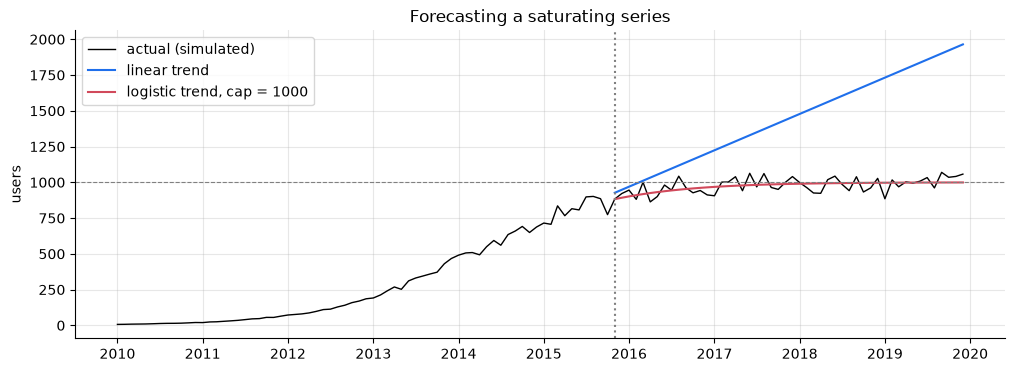

In [15]:
growth_rng = np.random.default_rng(0)
months = pd.date_range("2010-01-01", periods=120, freq="MS")
t = np.arange(120)
adoption = 1000 / (1 + np.exp(-(t - 50) / 10)) * (1 + 0.05 * growth_rng.normal(size=120))
seen, unseen = slice(0, 70), slice(70, 120)

flat_seasons = dict(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False, uncertainty_samples=0)
history_df = pd.DataFrame({"ds": months[seen], "y": adoption[seen]})
linear = Prophet(**flat_seasons).fit(history_df)
logistic = Prophet(growth="logistic", **flat_seasons).fit(history_df.assign(cap=1000))

future_df = pd.DataFrame({"ds": months[unseen]})
linear_fc = linear.predict(future_df)["yhat"].to_numpy()
logistic_fc = logistic.predict(future_df.assign(cap=1000))["yhat"].to_numpy()

fig, ax = plt.subplots()
ax.plot(months, adoption, color="k", lw=1, label="actual (simulated)")
ax.plot(months[unseen], linear_fc, label="linear trend")
ax.plot(months[unseen], logistic_fc, label="logistic trend, cap = 1000")
ax.axvline(months[70], color="0.5", ls=":")
ax.axhline(1000, color="0.5", ls="--", lw=0.8)
ax.set(title="Forecasting a saturating series", ylabel="users")
ax.legend()
print(f"MAE over the unseen 50 months: linear {np.mean(np.abs(linear_fc - adoption[unseen])):.0f}, "
      f"logistic {np.mean(np.abs(logistic_fc - adoption[unseen])):.0f}")

The linear trend extrapolates the steep middle of the S-curve and ends up at about double the ceiling. The logistic trend bends and levels off near 1,000, and its error is roughly a tenth of the linear one.

The catch is that **the logistic model is only as good as the cap you give it.** Here we knew the true ceiling. In practice the cap is a strong assumption, such as market size or population, and a wrong cap produces confidently wrong forecasts in the other direction. Use logistic growth when a genuine, knowable limit exists, and treat the cap as a scenario to vary, not a fact.

---
## 8. When is Prophet the right tool?

Prophet's reputation for losing benchmarks is deserved *on series like ours*: persistent (CO₂) or strongly autocorrelated (PM2.5), where the latest observation carries information that a calendar-driven curve ignores. Its strengths are real, but they lie elsewhere:

| Prophet is a good fit when… | Prefer dynamic models (ETS, ARIMA) when… |
|---|---|
| there are **several seasonal cycles** (daily + weekly + yearly) | there's one clean seasonal cycle |
| **holidays and events** drive large, known-in-advance effects | calendar effects are minor |
| data are **irregular or have gaps**, since no regular spacing is needed | observations are regular and complete |
| you need to forecast **hundreds of series** with little tuning and explain the parts to non-specialists | a few important series justify careful modelling |
| the horizon is **long relative to the memory** of the series | short-horizon accuracy matters most |

Whatever the choice, the chapter's checks carry over:
1. **Backtest against baselines.** Prophet with its defaults lost to seasonal naive + drift on CO₂.
2. **Check `changepoint_range`** whenever recent trend changes matter.
3. **Look at the residual ACF.** If it shows memory, a hybrid with an AR model on the residuals is cheap and effective.

---
## Exercises

### Exercise 1: Our Fourier features are Prophet's Fourier features
Prophet exposes its feature builder as `Prophet.fourier_series(dates, period, series_order)`, where `dates` is a pandas Series. Check that it matches `fourier_features` for the dates in `wiggle`, with period 365.25 and order 3.

<details><summary>Solution</summary>

```python
ours = fourier_features(wiggle.index, 365.25, 3)
theirs = Prophet.fourier_series(pd.Series(wiggle.index), 365.25, 3)
print("identical:", np.allclose(ours, theirs))
```
Both measure time in days since 1970 and interleave `sin`, `cos` for each order. There's nothing mysterious inside Prophet's seasonality: it's linear regression on these columns, with a prior (`seasonality_prior_scale`) that shrinks the coefficients.
</details>

### Exercise 2: How flexible should the trend be?
Fit Prophet to `co2_history` with `changepoint_prior_scale` set to 0.001, 0.05 (the default) and 0.5, keeping `changepoint_range=0.95`. Plot the three fitted **trend** components (the `trend` column of `predict`) on one chart. Which looks like overfitting, and which like underfitting?

<details><summary>Solution</summary>

```python
fig, ax = plt.subplots()
for scale in [0.001, 0.05, 0.5]:
    model = Prophet(weekly_seasonality=False, daily_seasonality=False, changepoint_range=0.95,
                    changepoint_prior_scale=scale).fit(to_prophet(co2_history))
    trend = model.predict(to_prophet(co2_history))["trend"]
    ax.plot(co2_history.index, trend, label=f"changepoint_prior_scale = {scale}")
ax.set(title="Prophet trend on CO₂ for different changepoint priors", ylabel="ppm")
ax.legend();
```
At 0.001 the trend is almost a single straight line. It can't follow the curvature of 35 years of accelerating growth, which is underfitting. At 0.5 the trend bends freely and starts absorbing wiggles that belong to seasonality and noise, which is overfitting risk, and every extra bend near the end is extrapolated into the forecast. The default sits in between. Tune this setting with a backtest, not by eye.
</details>

### Exercise 3: Are Prophet's intervals honest?
Prophet produces intervals with `interval_width=0.8` and `uncertainty_samples > 0`. Using **every seventh** origin in `origins` (to keep the runtime down), fit Prophet on the log scale with holidays, compute 80% intervals for the next 7 days, exponentiate them, and measure the coverage by horizon.

<details><summary>Solution</summary>

```python
coverage_rows = []
for origin_ in origins[::7]:
    history_ = y[:origin_]
    model = Prophet(holidays=holidays, interval_width=0.8, uncertainty_samples=300).fit(to_prophet(history_, log=True))
    future = pd.DataFrame({"ds": pd.date_range(origin_ + pd.Timedelta(days=1), periods=H, freq="D")})
    band = model.predict(future)
    target = actual.reindex(future["ds"]).to_numpy()
    inside = (target >= np.exp(band["yhat_lower"].to_numpy())) & (target <= np.exp(band["yhat_upper"].to_numpy()))
    coverage_rows.append(np.where(np.isnan(target), np.nan, inside))

pd.Series(np.nanmean(coverage_rows, axis=0), index=pd.RangeIndex(1, H + 1, name="days ahead"),
          name="coverage of 80% interval").round(2)
```
Coverage averages roughly three in four, below the promised 80%, with individual horizons scattered between the mid-60s and mid-80s. Prophet's intervals combine noise from the fitted error variance with simulated future trend changes, but they assume **independent** errors. PM2.5's errors come in multi-day runs, so the intervals are too narrow. With only about 50 origins these estimates are noisy, which is why some horizons land above 80% by chance. Compare chapter 06's AR(2), whose intervals were close to 80% because the model includes the autocorrelation.
</details>

### Exercise 4: Multiple seasonality on hourly data
Prophet's natural habitat is sub-daily data with several cycles. Fit it to **hourly** log PM2.5 for January–March 2014 (drop missing hours; Prophet doesn't need a regular grid), with daily and weekly seasonality and no yearly seasonality. Plot the components. Does the daily profile match what chapter 01 found?

<details><summary>Solution</summary>

```python
hourly_q1 = hourly_pm["2014-01":"2014-03"].dropna()
hourly_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False,
                       uncertainty_samples=0).fit(to_prophet(hourly_q1, log=True))
hourly_model.plot_components(hourly_model.predict(to_prophet(hourly_q1, log=True)))

one_day = pd.DataFrame({"ds": pd.date_range("2014-01-06", periods=24, freq="h")})
daily_cycle = np.exp(hourly_model.predict(one_day)["daily"]) - 1
print((100 * daily_cycle).round(0).set_axis(range(24)).to_string())
```
Yes. The daily component is highest in the late evening and around midnight, and lowest in mid-afternoon, the same cycle chapter 01 found with a simple group-by. The mechanism is the daytime mixing of the lower atmosphere and its collapse at night. Prophet fitted it together with the weekly cycle and a trend, straight from irregular hourly data. That flexibility is where Prophet earns its place.
</details>

---
## Key takeaways

- Prophet models a series as **trend + Fourier seasonality + holidays**, a curve fitted to the calendar, with **no autoregressive memory**.
- **Fourier order** sets seasonal flexibility, and **changepoints** let the trend bend. By default they stop at **80% of the history**, which made Prophet lose to a simple baseline on CO₂ until we set `changepoint_range=0.95`.
- **Holidays** capture real, known-in-advance effects: Spring Festival fireworks lift New Year's Day PM2.5 by roughly half. Each is estimated from only a few occurrences.
- On PM2.5, Prophet alone is **climatology-like**. A **hybrid** with AR(2) on its residuals matches chapter 06's best memory-based model. Its intervals run narrow because they ignore autocorrelated errors.
- **Extra regressors** must be known on the forecast dates *and* add information the model lacks. A heating-season flag didn't, because yearly seasonality already knew when winter was. A **logistic trend** handles saturation, but it's only as good as its cap.
- Prophet shines with **multiple seasonalities, holidays, irregular data and many series**. On persistent or strongly autocorrelated series, dynamic models usually win. Always **backtest against baselines** and **inspect the residual ACF**.

**Next:** *09 · Machine Learning for Forecasting*. We'll turn forecasting into a supervised-learning problem with lag and calendar features, use gradient boosting, and meet the leakage traps that come with it.